## Partie 4 : Régression — Prédiction de `Prix_Revente`

> Variable cible : **`Prix_Revente`** | Split : **70 % Train | 15 % Val | 15 % Test** (stratifié sur `Categorie`)

In [34]:
target_reg = 'Prix_Revente'
X_reg      = df_clean.drop(['Categorie', 'Rapport_Collecte', target_reg], axis=1)
y_reg      = df_clean[target_reg].reset_index(drop=True)
cat_strat  = df_clean['Categorie'].reset_index(drop=True)

scaler_reg   = StandardScaler()
X_reg_scaled = pd.DataFrame(scaler_reg.fit_transform(X_reg), columns=X_reg.columns)

X_r_train, X_r_temp, y_r_train, y_r_temp, cat_train, cat_temp = train_test_split(
    X_reg_scaled, y_reg, cat_strat,
    test_size=0.30, random_state=42, stratify=cat_strat
)

X_r_val, X_r_test, y_r_val, y_r_test = train_test_split(
    X_r_temp, y_r_temp,
    test_size=0.50, random_state=42, stratify=cat_temp
)

print(f"Train Reg : {X_r_train.shape} | Val Reg : {X_r_val.shape} | Test Reg : {X_r_test.shape}")

def reg_metrics(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{name:<35} RMSE: {rmse:9.3f} | MAE: {mae:9.3f} | R2: {r2:.4f}")
    return rmse, mae, r2

Train Reg : (6734, 6) | Val Reg : (1443, 6) | Test Reg : (1443, 6)


### 4.1 — Régression Linéaire (OLS)

In [35]:
ols = LinearRegression()
ols.fit(X_r_train, y_r_train)
y_pred_ols = ols.predict(X_r_test)
ols_rmse, ols_mae, ols_r2 = reg_metrics("Régression Linéaire (OLS)", y_r_test, y_pred_ols)

Régression Linéaire (OLS)           RMSE:     2.481 | MAE:     1.923 | R2: 0.7563


### 4.2 — Ridge

In [36]:
best_alpha_ridge, best_r2_val = 0.1, -np.inf
for a in [0.01, 0.1, 1, 10, 100]:
    ridge_tmp = Ridge(alpha=a)
    ridge_tmp.fit(X_r_train, y_r_train)
    r2_v = r2_score(y_r_val, ridge_tmp.predict(X_r_val))
    if r2_v > best_r2_val:
        best_r2_val, best_alpha_ridge = r2_v, a

print(f"Meilleur alpha Ridge = {best_alpha_ridge}  |  Val R2 = {best_r2_val:.4f}")
ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_r_train, y_r_train)
y_pred_ridge = ridge.predict(X_r_test)
ridge_rmse, ridge_mae, ridge_r2 = reg_metrics("Ridge", y_r_test, y_pred_ridge)

Meilleur alpha Ridge = 0.01  |  Val R2 = 0.7535
Ridge                               RMSE:     2.481 | MAE:     1.923 | R2: 0.7563


### 4.3 — Lasso

In [37]:
best_alpha_lasso, best_r2_val = 0.001, -np.inf
for a in [0.0001, 0.001, 0.01, 0.1, 1]:
    lasso_tmp = Lasso(alpha=a, max_iter=5000)
    lasso_tmp.fit(X_r_train, y_r_train)
    r2_v = r2_score(y_r_val, lasso_tmp.predict(X_r_val))
    if r2_v > best_r2_val:
        best_r2_val, best_alpha_lasso = r2_v, a

print(f"Meilleur alpha Lasso = {best_alpha_lasso}  |  Val R2 = {best_r2_val:.4f}")
lasso = Lasso(alpha=best_alpha_lasso, max_iter=5000)
lasso.fit(X_r_train, y_r_train)
y_pred_lasso = lasso.predict(X_r_test)
lasso_rmse, lasso_mae, lasso_r2 = reg_metrics("Lasso", y_r_test, y_pred_lasso)

Meilleur alpha Lasso = 0.0001  |  Val R2 = 0.7535
Lasso                               RMSE:     2.481 | MAE:     1.923 | R2: 0.7563


### 4.4 — k-NN Régression

In [38]:
best_k_r, best_r2_val = 1, -np.inf
for k in range(1, 21):
    knnr_tmp = KNeighborsRegressor(n_neighbors=k)
    knnr_tmp.fit(X_r_train, y_r_train)
    r2_v = r2_score(y_r_val, knnr_tmp.predict(X_r_val))
    if r2_v > best_r2_val:
        best_r2_val, best_k_r = r2_v, k

print(f"Meilleur k (Régression) = {best_k_r}  |  Val R2 = {best_r2_val:.4f}")
knnr = KNeighborsRegressor(n_neighbors=best_k_r)
knnr.fit(X_r_train, y_r_train)
y_pred_knnr = knnr.predict(X_r_test)
knnr_rmse, knnr_mae, knnr_r2 = reg_metrics(f"kNN Regression (k={best_k_r})", y_r_test, y_pred_knnr)

Meilleur k (Régression) = 1  |  Val R2 = 0.9735
kNN Regression (k=1)                RMSE:     0.719 | MAE:     0.155 | R2: 0.9795


### 4.5 — Decision Tree Régression

In [39]:
best_depth_r, best_r2_val = None, -np.inf
for d in [None, 3, 5, 7, 10]:
    dtr_tmp = DecisionTreeRegressor(max_depth=d, random_state=42)
    dtr_tmp.fit(X_r_train, y_r_train)
    r2_v = r2_score(y_r_val, dtr_tmp.predict(X_r_val))
    if r2_v > best_r2_val:
        best_r2_val, best_depth_r = r2_v, d

print(f"Meilleur max_depth (Régression) = {best_depth_r}  |  Val R2 = {best_r2_val:.4f}")
dtr = DecisionTreeRegressor(max_depth=best_depth_r, random_state=42)
dtr.fit(X_r_train, y_r_train)
y_pred_dtr = dtr.predict(X_r_test)
dtr_rmse, dtr_mae, dtr_r2 = reg_metrics(f"Decision Tree Reg (depth={best_depth_r})", y_r_test, y_pred_dtr)

Meilleur max_depth (Régression) = 10  |  Val R2 = 0.9799
Decision Tree Reg (depth=10)        RMSE:     0.779 | MAE:     0.187 | R2: 0.9760


### 4.6 — Random Forest Régression

In [40]:
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_r_train, y_r_train)
y_pred_rfr = rfr.predict(X_r_test)
rfr_rmse, rfr_mae, rfr_r2 = reg_metrics("Random Forest Regression", y_r_test, y_pred_rfr)

cv_rfr = cross_val_score(rfr, X_r_train, y_r_train, cv=5, scoring='r2')
print(f"CV R2 (5 folds) : {cv_rfr.round(3)} | Moyenne : {cv_rfr.mean():.3f} ± {cv_rfr.std():.3f}")

Random Forest Regression            RMSE:     0.716 | MAE:     0.161 | R2: 0.9797
CV R2 (5 folds) : [0.992 0.995 0.987 0.989 0.978] | Moyenne : 0.988 ± 0.006


### 4.7 — SVR (kernel RBF)

In [41]:
svr = SVR(kernel='rbf')
svr.fit(X_r_train, y_r_train)
y_pred_svr = svr.predict(X_r_test)
svr_rmse, svr_mae, svr_r2 = reg_metrics("SVR (RBF)", y_r_test, y_pred_svr)

SVR (RBF)                           RMSE:     1.195 | MAE:     0.453 | R2: 0.9435


### 4.8 — Gradient Boosting Régression

In [42]:
gbr = GradientBoostingRegressor(n_estimators=100, random_state=42)
gbr.fit(X_r_train, y_r_train)
y_pred_gbr = gbr.predict(X_r_test)
gbr_rmse, gbr_mae, gbr_r2 = reg_metrics("Gradient Boosting Regression", y_r_test, y_pred_gbr)

Gradient Boosting Regression        RMSE:     0.800 | MAE:     0.276 | R2: 0.9747


## Partie 5 : Tableau Comparatif — Régression

In [43]:
results_reg = pd.DataFrame([
    {'Algorithme': 'Régression Linéaire',        'RMSE': ols_rmse,   'MAE': ols_mae,   'R2': ols_r2},
    {'Algorithme': 'Ridge',                      'RMSE': ridge_rmse, 'MAE': ridge_mae, 'R2': ridge_r2},
    {'Algorithme': 'Lasso',                      'RMSE': lasso_rmse, 'MAE': lasso_mae, 'R2': lasso_r2},
    {'Algorithme': f'kNN Reg (k={best_k_r})',    'RMSE': knnr_rmse,  'MAE': knnr_mae,  'R2': knnr_r2},
    {'Algorithme': 'Decision Tree Reg',          'RMSE': dtr_rmse,   'MAE': dtr_mae,   'R2': dtr_r2},
    {'Algorithme': 'Random Forest Reg',          'RMSE': rfr_rmse,   'MAE': rfr_mae,   'R2': rfr_r2},
    {'Algorithme': 'SVR (RBF)',                  'RMSE': svr_rmse,   'MAE': svr_mae,   'R2': svr_r2},
    {'Algorithme': 'Gradient Boosting',          'RMSE': gbr_rmse,   'MAE': gbr_mae,   'R2': gbr_r2},
]).set_index('Algorithme').round(4).sort_values('R2', ascending=False)

print("Classement des modèles de Régression (ensemble Test) :")
display(results_reg.style.background_gradient(cmap='YlGn', subset=['R2'])
                         .background_gradient(cmap='YlOrRd_r', subset=['RMSE', 'MAE']))

Classement des modèles de Régression (ensemble Test) :


,RMSE,MAE,R2
Algorithme,,,
Random Forest Reg,0.716100,0.160900,0.979700
kNN Reg (k=1),0.718900,0.155200,0.979500
Decision Tree Reg,0.778800,0.187200,0.976000
Gradient Boosting,0.799900,0.276100,0.974700
SVR (RBF),1.195000,0.453200,0.943500
Lasso,2.480700,1.923200,0.756300
Régression Linéaire,2.480700,1.923200,0.756300
Ridge,2.480700,1.923200,0.756300


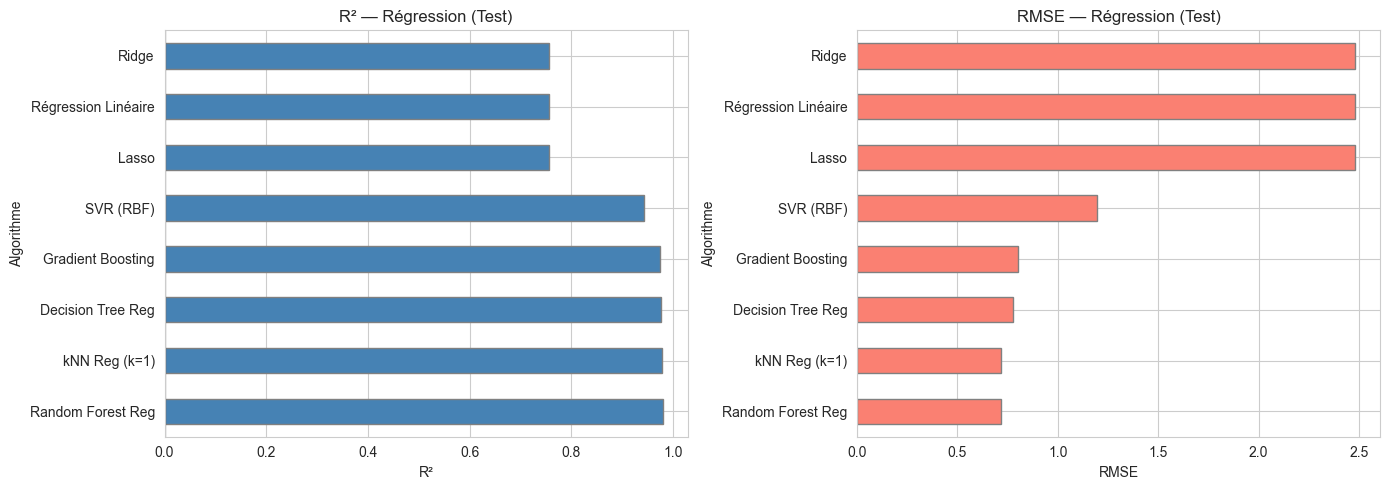

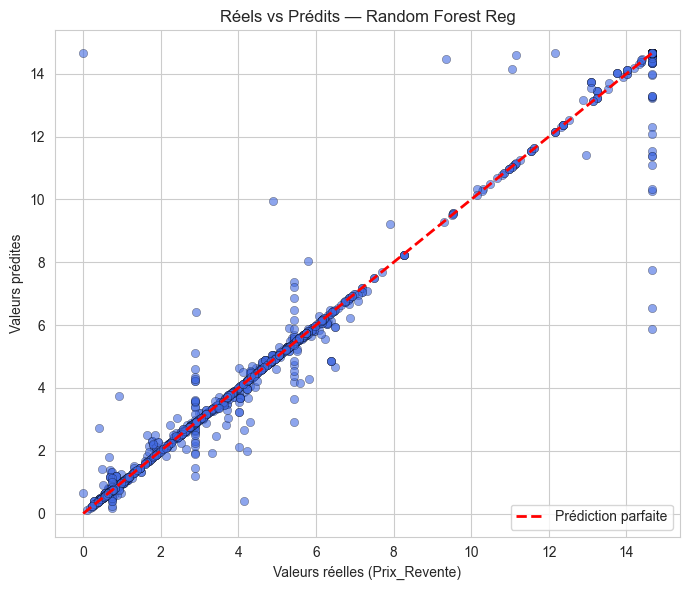

Meilleur modèle : Random Forest Reg  |  R² = 0.9797


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

results_reg['R2'].plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='grey')
axes[0].set_title('R² — Régression (Test)', fontsize=12)
axes[0].set_xlabel('R²')
axes[0].axvline(0, color='black', linewidth=0.8)

results_reg['RMSE'].plot(kind='barh', ax=axes[1], color='salmon', edgecolor='grey')
axes[1].set_title('RMSE — Régression (Test)', fontsize=12)
axes[1].set_xlabel('RMSE')

plt.tight_layout()
plt.show()

# Réels vs prédits — meilleur modèle
best_reg_name = results_reg['R2'].idxmax()
best_preds_map = {
    'Régression Linéaire'       : y_pred_ols,
    'Ridge'                     : y_pred_ridge,
    'Lasso'                     : y_pred_lasso,
    f'kNN Reg (k={best_k_r})'   : y_pred_knnr,
    'Decision Tree Reg'         : y_pred_dtr,
    'Random Forest Reg'         : y_pred_rfr,
    'SVR (RBF)'                 : y_pred_svr,
    'Gradient Boosting'         : y_pred_gbr,
}
best_y_pred = best_preds_map[best_reg_name]

plt.figure(figsize=(7, 6))
plt.scatter(y_r_test, best_y_pred, alpha=0.6, edgecolors='k', linewidths=0.3, color='royalblue')
lims = [min(y_r_test.min(), best_y_pred.min()), max(y_r_test.max(), best_y_pred.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Prédiction parfaite')
plt.xlabel('Valeurs réelles (Prix_Revente)')
plt.ylabel('Valeurs prédites')
plt.title(f'Réels vs Prédits — {best_reg_name}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Meilleur modèle : {best_reg_name}  |  R² = {results_reg.loc[best_reg_name, 'R2']:.4f}")